# Prédire si une personne risque l'AVC ou pas

In [1]:
# Acquisition
import os

listeDeFichiers = os.listdir("../data")

for fichier in listeDeFichiers:
    print(fichier)

healthcare-dataset-stroke-data.csv


In [2]:
# preparation des données
import pandas as pd

nosPatients = pd.read_csv("../data/healthcare-dataset-stroke-data.csv")
nosPatients = nosPatients.drop(columns=["id"])

print(nosPatients.columns.values)
print(nosPatients.head(10))
print(nosPatients.shape)
print(nosPatients.info())

['gender' 'age' 'hypertension' 'heart_disease' 'ever_married' 'work_type'
 'Residence_type' 'avg_glucose_level' 'bmi' 'smoking_status' 'stroke']
   gender   age  hypertension  heart_disease ever_married      work_type  \
0    Male  67.0             0              1          Yes        Private   
1  Female  61.0             0              0          Yes  Self-employed   
2    Male  80.0             0              1          Yes        Private   
3  Female  49.0             0              0          Yes        Private   
4  Female  79.0             1              0          Yes  Self-employed   
5    Male  81.0             0              0          Yes        Private   
6    Male  74.0             1              1          Yes        Private   
7  Female  69.0             0              0           No        Private   
8  Female  59.0             0              0          Yes        Private   
9  Female  78.0             0              0          Yes        Private   

  Residence_type  

In [3]:
# diagnostic
nosPatients['bmi'] = pd.to_numeric(nosPatients['bmi'], errors='coerce')

print("Valeurs manquantes par colonne :")
print(nosPatients.isnull().sum())

print("\nNombre de doublons :", nosPatients.duplicated().sum())

print("\nStatistiques descriptives :")
print(nosPatients.describe())

Valeurs manquantes par colonne :
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

Nombre de doublons : 0

Statistiques descriptives :
               age  hypertension  heart_disease  avg_glucose_level  \
count  5110.000000   5110.000000    5110.000000        5110.000000   
mean     43.226614      0.097456       0.054012         106.147677   
std      22.612647      0.296607       0.226063          45.283560   
min       0.080000      0.000000       0.000000          55.120000   
25%      25.000000      0.000000       0.000000          77.245000   
50%      45.000000      0.000000       0.000000          91.885000   
75%      61.000000      0.000000       0.000000         114.090000   
max      82.000000      1.000000       1.000000         271.740000

In [4]:
# nettoyage
medianeBmi = nosPatients['bmi'].median()
print("Médiane de bmi utilisée pour l'imputation :", medianeBmi)

nosPatients['bmi'] = nosPatients['bmi'].fillna(medianeBmi)

print("\nValeurs manquantes après imputation :")
print(nosPatients.isnull().sum())

print("\nRépartition de gender avant nettoyage :")
print(nosPatients['gender'].value_counts())

# Suppression de la catégorie 'Other', trop rare pour être exploitable
nosPatients = nosPatients[nosPatients['gender'] != 'Other']

Médiane de bmi utilisée pour l'imputation : 28.1

Valeurs manquantes après imputation :
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Répartition de gender avant nettoyage :
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


Nombre de patients par classe :
stroke
0    4860
1     249
Name: count, dtype: int64

Pourcentage par classe :
stroke
0    95.13
1     4.87
Name: proportion, dtype: float64


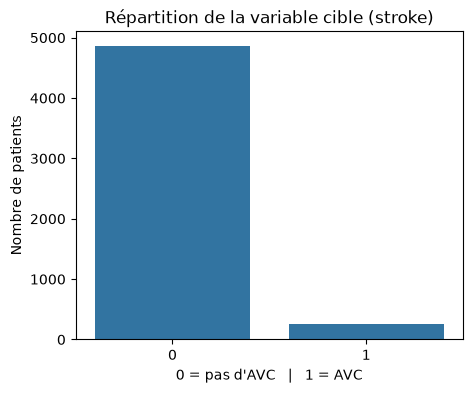

In [5]:
# exploration de la variable cible
repartition = nosPatients['stroke'].value_counts()
pourcentage = nosPatients['stroke'].value_counts(normalize=True) * 100

print("Nombre de patients par classe :")
print(repartition)
print("\nPourcentage par classe :")
print(pourcentage.round(2))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.countplot(x='stroke', data=nosPatients)
plt.title("Répartition de la variable cible (stroke)")
plt.xlabel("0 = pas d'AVC   |   1 = AVC")
plt.ylabel("Nombre de patients")
plt.show()

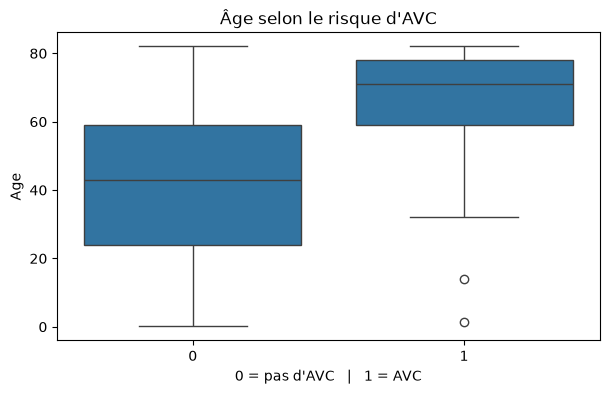

         count       mean        std   min   25%   50%   75%   max
stroke                                                            
0       4860.0  41.974831  22.293056  0.08  24.0  43.0  59.0  82.0
1        249.0  67.728193  12.727419  1.32  59.0  71.0  78.0  82.0


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# qge selon le risque d'AVC
plt.figure(figsize=(7, 4))
sns.boxplot(x='stroke', y='age', data=nosPatients)
plt.xlabel("0 = pas d'AVC   |   1 = AVC")
plt.ylabel("Age")
plt.title("Âge selon le risque d'AVC")
plt.show()

print(nosPatients.groupby('stroke')['age'].describe())

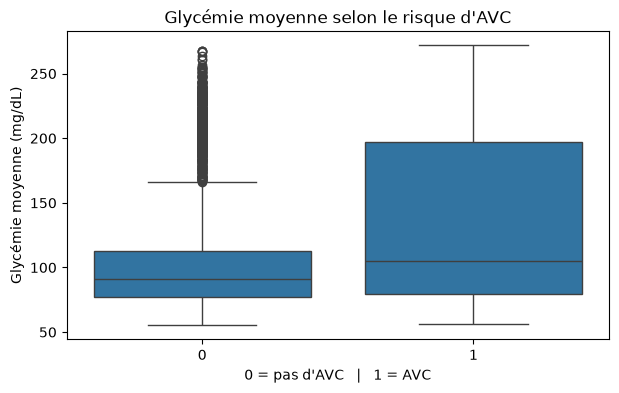

         count        mean        std    min    25%      50%     75%     max
stroke                                                                      
0       4860.0  104.787584  43.847095  55.12  77.12   91.465  112.80  267.76
1        249.0  132.544739  61.921056  56.11  79.79  105.220  196.71  271.74


In [7]:
# Glycémie moyenne selon le risque d'AVC
plt.figure(figsize=(7, 4))
sns.boxplot(x='stroke', y='avg_glucose_level', data=nosPatients)
plt.xlabel("0 = pas d'AVC   |   1 = AVC")
plt.ylabel("Glycémie moyenne (mg/dL)")
plt.title("Glycémie moyenne selon le risque d'AVC")
plt.show()

print(nosPatients.groupby('stroke')['avg_glucose_level'].describe())

In [8]:
# Hypertension et maladie cardiaque : deux facteurs de risque cliniques connus
print("Taux d'AVC selon hypertension (%) :")
print((nosPatients.groupby('hypertension')['stroke'].mean() * 100).round(2))

print("\nTaux d'AVC selon maladie cardiaque (%) :")
print((nosPatients.groupby('heart_disease')['stroke'].mean() * 100).round(2))

Taux d'AVC selon hypertension (%) :
hypertension
0     3.97
1    13.25
Name: stroke, dtype: float64

Taux d'AVC selon maladie cardiaque (%) :
heart_disease
0     4.18
1    17.03
Name: stroke, dtype: float64


In [9]:
# encodage des variables catégorielles
nouveauDataset = nosPatients.copy()

colonnesCategorielles = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

nouveauDataset = pd.get_dummies(nouveauDataset, columns=colonnesCategorielles, drop_first=True)

print("Colonnes après encodage :")
print(nouveauDataset.columns.values)
print("\nNouvelle forme du dataset :", nouveauDataset.shape)
print(nouveauDataset.head())

Colonnes après encodage :
['age' 'hypertension' 'heart_disease' 'avg_glucose_level' 'bmi' 'stroke'
 'gender_Male' 'ever_married_Yes' 'work_type_Never_worked'
 'work_type_Private' 'work_type_Self-employed' 'work_type_children'
 'Residence_type_Urban' 'smoking_status_formerly smoked'
 'smoking_status_never smoked' 'smoking_status_smokes']

Nouvelle forme du dataset : (5109, 16)
    age  hypertension  heart_disease  avg_glucose_level   bmi  stroke  \
0  67.0             0              1             228.69  36.6       1   
1  61.0             0              0             202.21  28.1       1   
2  80.0             0              1             105.92  32.5       1   
3  49.0             0              0             171.23  34.4       1   
4  79.0             1              0             174.12  24.0       1   

   gender_Male  ever_married_Yes  work_type_Never_worked  work_type_Private  \
0         True              True                   False               True   
1        False          

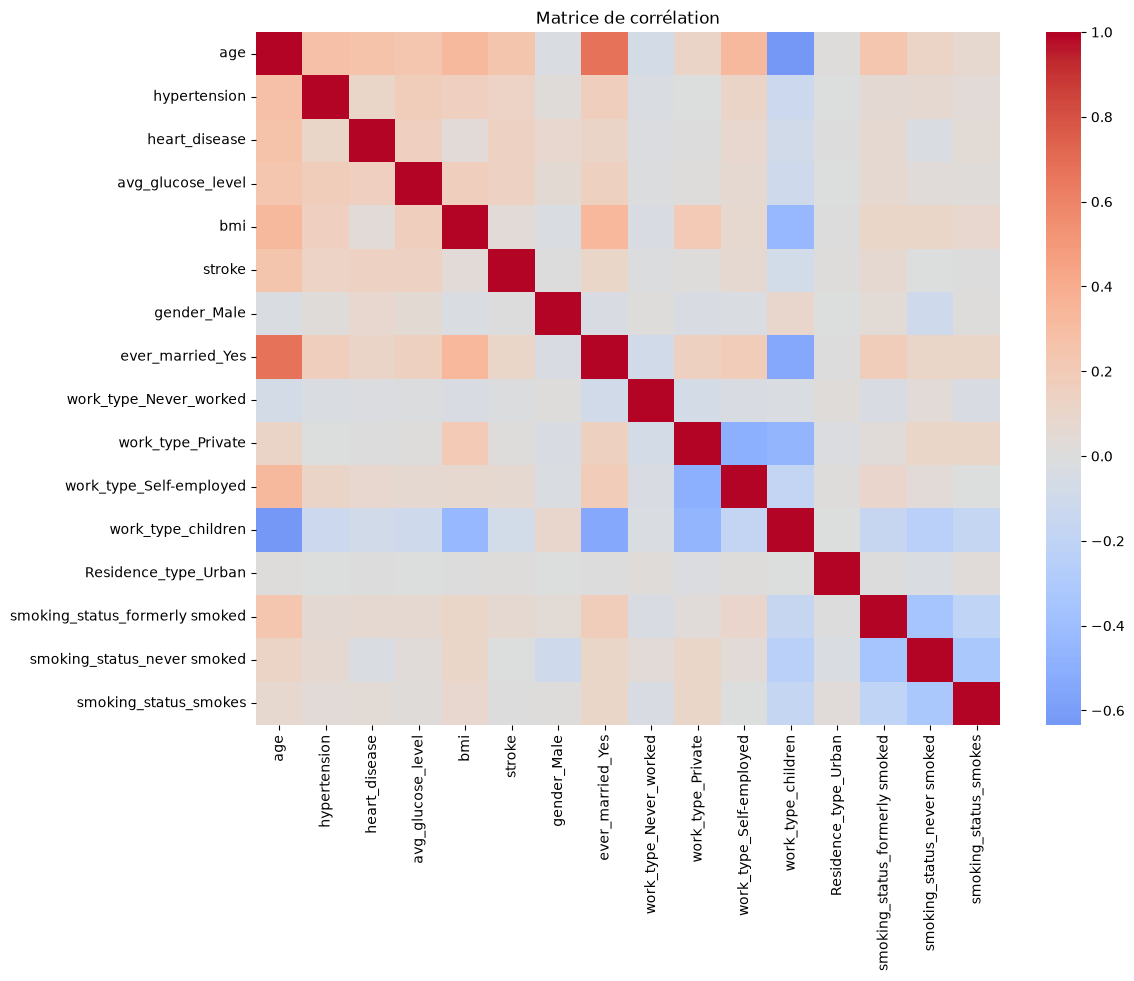

Corrélation de chaque variable avec la cible 'stroke' (triée) :
stroke                            1.000000
age                               0.245239
heart_disease                     0.134905
avg_glucose_level                 0.131991
hypertension                      0.127891
ever_married_Yes                  0.108299
smoking_status_formerly smoked    0.064683
work_type_Self-employed           0.062150
bmi                               0.036075
Residence_type_Urban              0.015415
work_type_Private                 0.011927
gender_Male                       0.009081
smoking_status_smokes             0.008920
smoking_status_never smoked      -0.004163
work_type_Never_worked           -0.014885
work_type_children               -0.083888
Name: stroke, dtype: float64


In [10]:
# matrice de correlation
plt.close('all')
plt.figure(figsize=(12, 9))
corr = nouveauDataset.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()

print("Corrélation de chaque variable avec la cible 'stroke' (triée) :")
print(corr['stroke'].sort_values(ascending=False))

In [11]:
# preparation du dataset 
X = nouveauDataset.drop(columns=['stroke'])
y = nouveauDataset['stroke']

print("Forme de X :", X.shape)
print("Forme de y :", y.shape)
print("\nColonnes de X :")
print(X.columns.values)

Forme de X : (5109, 15)
Forme de y : (5109,)

Colonnes de X :
['age' 'hypertension' 'heart_disease' 'avg_glucose_level' 'bmi'
 'gender_Male' 'ever_married_Yes' 'work_type_Never_worked'
 'work_type_Private' 'work_type_Self-employed' 'work_type_children'
 'Residence_type_Urban' 'smoking_status_formerly smoked'
 'smoking_status_never smoked' 'smoking_status_smokes']


In [12]:
# separation du dataset en apprentissage et validation
from sklearn.model_selection import train_test_split

X_APPRENTISSAGE, X_VALIDATION, Y_APPRENTISSAGE, Y_VALIDATION = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

print("Taille apprentissage :", X_APPRENTISSAGE.shape)
print("Taille validation :", X_VALIDATION.shape)

print("\nProportion d'AVC (apprentissage) :", round(Y_APPRENTISSAGE.mean(), 4))
print("Proportion d'AVC (validation)   :", round(Y_VALIDATION.mean(), 4))

Taille apprentissage : (4087, 15)
Taille validation : (1022, 15)

Proportion d'AVC (apprentissage) : 0.0487
Proportion d'AVC (validation)   : 0.0489


In [13]:
# Reequilibrage des classes avec SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=0)
X_APPRENTISSAGE_SMOTE, Y_APPRENTISSAGE_SMOTE = smote.fit_resample(X_APPRENTISSAGE, Y_APPRENTISSAGE)

print("Avant SMOTE :")
print(Y_APPRENTISSAGE.value_counts())

print("\nAprès SMOTE :")
print(Y_APPRENTISSAGE_SMOTE.value_counts())

Avant SMOTE :
stroke
0    3888
1     199
Name: count, dtype: int64

Après SMOTE :
stroke
0    3888
1    3888
Name: count, dtype: int64


In [14]:
# entrainement et comparaison de plusieurs modèles 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, roc_auc_score)

def evaluer(nom, modele, X_train, y_train, X_val, y_val):
    modele.fit(X_train, y_train)
    predictions = modele.predict(X_val)
    probabilites = modele.predict_proba(X_val)[:, 1]

    resultat = {
        "modele": nom,
        "accuracy": accuracy_score(y_val, predictions),
        "recall (classe AVC)": recall_score(y_val, predictions),
        "precision (classe AVC)": precision_score(y_val, predictions, zero_division=0),
        "f1 (classe AVC)": f1_score(y_val, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_val, probabilites),
    }
    return resultat, modele

resultats = []

r, _ = evaluer("LogisticRegression (naif)", LogisticRegression(max_iter=1000),
               X_APPRENTISSAGE, Y_APPRENTISSAGE, X_VALIDATION, Y_VALIDATION)
resultats.append(r)

r, _ = evaluer("LogisticRegression (class_weight)", LogisticRegression(max_iter=1000, class_weight='balanced'),
               X_APPRENTISSAGE, Y_APPRENTISSAGE, X_VALIDATION, Y_VALIDATION)
resultats.append(r)

r, _ = evaluer("LogisticRegression (SMOTE)", LogisticRegression(max_iter=1000),
               X_APPRENTISSAGE_SMOTE, Y_APPRENTISSAGE_SMOTE, X_VALIDATION, Y_VALIDATION)
resultats.append(r)

r, _ = evaluer("RandomForest (naif)", RandomForestClassifier(random_state=0),
               X_APPRENTISSAGE, Y_APPRENTISSAGE, X_VALIDATION, Y_VALIDATION)
resultats.append(r)

r, modeleRetenu = evaluer("RandomForest (class_weight)", RandomForestClassifier(random_state=0, class_weight='balanced'),
               X_APPRENTISSAGE, Y_APPRENTISSAGE, X_VALIDATION, Y_VALIDATION)
resultats.append(r)

r, _ = evaluer("RandomForest (SMOTE)", RandomForestClassifier(random_state=0),
               X_APPRENTISSAGE_SMOTE, Y_APPRENTISSAGE_SMOTE, X_VALIDATION, Y_VALIDATION)
resultats.append(r)

tableauResultats = pd.DataFrame(resultats).set_index("modele").round(4)
print(tableauResultats)

                                   accuracy  recall (classe AVC)  \
modele                                                             
LogisticRegression (naif)            0.9521                 0.02   
LogisticRegression (class_weight)    0.7299                 0.70   
LogisticRegression (SMOTE)           0.8474                 0.38   
RandomForest (naif)                  0.9501                 0.00   
RandomForest (class_weight)          0.9403                 0.06   
RandomForest (SMOTE)                 0.9178                 0.18   

                                   precision (classe AVC)  f1 (classe AVC)  \
modele                                                                       
LogisticRegression (naif)                          1.0000           0.0392   
LogisticRegression (class_weight)                  0.1182           0.2023   
LogisticRegression (SMOTE)                         0.1319           0.1959   
RandomForest (naif)                                0.0000        

Rapport de classification complet :
              precision    recall  f1-score   support

   Pas d'AVC       0.98      0.73      0.84       972
         AVC       0.12      0.70      0.20        50

    accuracy                           0.73      1022
   macro avg       0.55      0.72      0.52      1022
weighted avg       0.94      0.73      0.81      1022



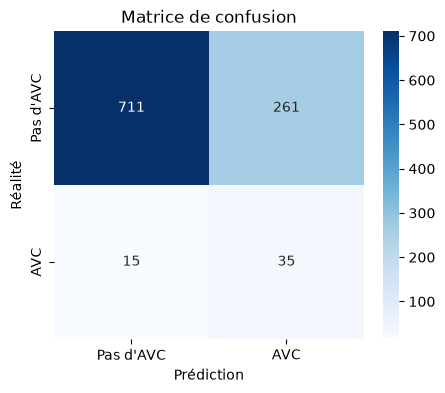

In [15]:
# analyse du modèle retenu
from sklearn.metrics import confusion_matrix, classification_report

meilleurModele = LogisticRegression(max_iter=1000, class_weight='balanced')
meilleurModele.fit(X_APPRENTISSAGE, Y_APPRENTISSAGE)
predictions = meilleurModele.predict(X_VALIDATION)

print("Rapport de classification complet :")
print(classification_report(Y_VALIDATION, predictions, target_names=["Pas d'AVC", "AVC"]))

matrice = confusion_matrix(Y_VALIDATION, predictions)
plt.close('all')
plt.figure(figsize=(5, 4))
sns.heatmap(matrice, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pas d'AVC", "AVC"], yticklabels=["Pas d'AVC", "AVC"])
plt.xlabel("Prédiction")
plt.ylabel("Réalité")
plt.title("Matrice de confusion")
plt.show()

work_type_children                1.0749
hypertension                      0.4738
heart_disease                     0.4009
smoking_status_smokes             0.3358
smoking_status_formerly smoked    0.1458
ever_married_Yes                  0.0884
age                               0.0825
Residence_type_Urban              0.0338
work_type_Private                 0.0193
bmi                               0.0049
avg_glucose_level                 0.0037
work_type_Self-employed          -0.1078
gender_Male                      -0.1105
work_type_Never_worked           -0.1316
smoking_status_never smoked      -0.1321
dtype: float64


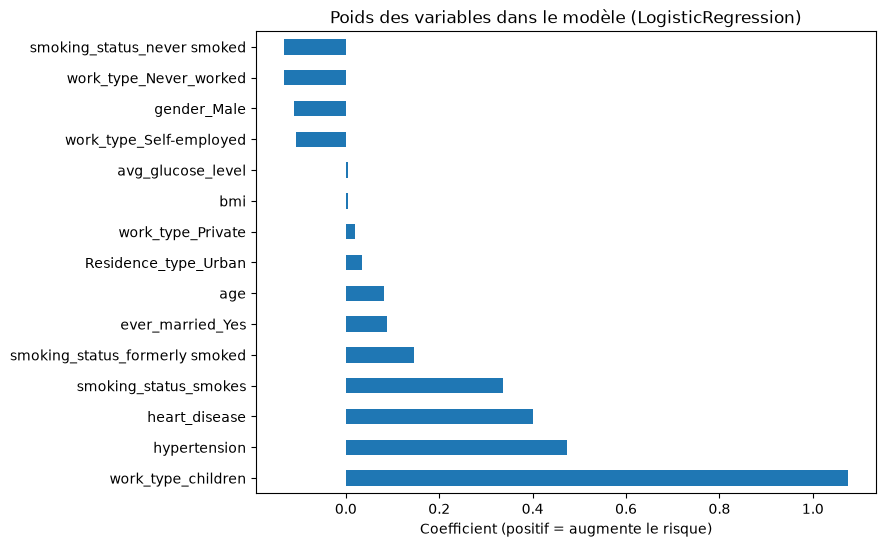

In [16]:
# importance des variables
coefficients = pd.Series(meilleurModele.coef_[0], index=X.columns)
coefficients = coefficients.sort_values(ascending=False)

print(coefficients.round(4))

plt.close('all')
plt.figure(figsize=(8, 6))
coefficients.plot(kind='barh')
plt.title("Poids des variables dans le modèle (LogisticRegression)")
plt.xlabel("Coefficient (positif = augmente le risque)")
plt.show()

Rapport de classification :
              precision    recall  f1-score   support

   Pas d'AVC       0.98      0.73      0.84       972
         AVC       0.12      0.70      0.20        50

    accuracy                           0.73      1022
   macro avg       0.55      0.72      0.52      1022
weighted avg       0.94      0.73      0.81      1022


Coefficients :
age                               1.8658
work_type_children                1.0785
hypertension                      0.4764
heart_disease                     0.4099
smoking_status_smokes             0.3334
avg_glucose_level                 0.1665
smoking_status_formerly smoked    0.1517
ever_married_Yes                  0.0914
bmi                               0.0355
Residence_type_Urban              0.0336
work_type_Private                 0.0223
work_type_Never_worked           -0.0707
work_type_Self-employed          -0.1033
gender_Male                      -0.1156
smoking_status_never smoked      -0.1307
dtype: float64

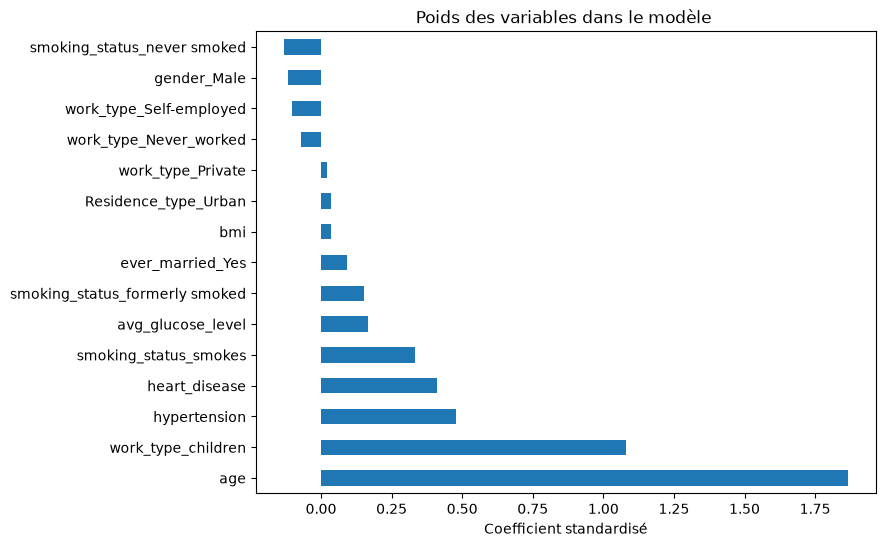

In [17]:
# correction : standardiser les variables numériques
from sklearn.preprocessing import StandardScaler

colonnesNumeriques = ['age', 'avg_glucose_level', 'bmi']

scaler = StandardScaler()

X_APPRENTISSAGE_STD = X_APPRENTISSAGE.copy()
X_VALIDATION_STD = X_VALIDATION.copy()

X_APPRENTISSAGE_STD[colonnesNumeriques] = scaler.fit_transform(X_APPRENTISSAGE[colonnesNumeriques])
X_VALIDATION_STD[colonnesNumeriques] = scaler.transform(X_VALIDATION[colonnesNumeriques])

# On réentraîne le modèle retenu sur les données standardisées
meilleurModele = LogisticRegression(max_iter=1000, class_weight='balanced')
meilleurModele.fit(X_APPRENTISSAGE_STD, Y_APPRENTISSAGE)
predictions = meilleurModele.predict(X_VALIDATION_STD)

print("Rapport de classification :")
print(classification_report(Y_VALIDATION, predictions, target_names=["Pas d'AVC", "AVC"]))

coefficients = pd.Series(meilleurModele.coef_[0], index=X.columns)
coefficients = coefficients.sort_values(ascending=False)
print("\nCoefficients :")
print(coefficients.round(4))

plt.close('all')
plt.figure(figsize=(8, 6))
coefficients.plot(kind='barh')
plt.title("Poids des variables dans le modèle ")
plt.xlabel("Coefficient standardisé")
plt.show()

In [18]:
# sauvegarde du modele reteny et scaler
import joblib
import os

os.makedirs("../modele", exist_ok=True)

joblib.dump(meilleurModele, "../modele/modele_avc.pkl")
joblib.dump(scaler, "../modele/scaler_avc.pkl")

print("Modèle sauvegardé dans : ../modele/modele_avc.pkl")
print("Scaler sauvegardé dans : ../modele/scaler_avc.pkl")

Modèle sauvegardé dans : ../modele/modele_avc.pkl
Scaler sauvegardé dans : ../modele/scaler_avc.pkl
